# Avance 2 - Ingeniería de Características y Modelamiento Supervisado

## Objetivo
En este avance se desarrolla el proceso de ingeniería de características y el entrenamiento de los primeros modelos supervisados para la predicción de churn.

Primero, se preparan las variables mediante imputación, codificación y escalamiento.

Luego, se entrenan distintos modelos de clasificación y se evalúa su desempeño para seleccionar el mejor modelo.

## Versionado
- Versión 1.1.0: Feature Engineering
- Versión 1.0.1: Modelamiento

In [98]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

sns.set(style="whitegrid")

In [100]:
df = pd.read_excel("../Base_de_datos.xlsx")

df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [102]:
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras filas:")
display(df.head())

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())

Dimensiones del dataset: (10763, 23)

Primeras filas:


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1



Tipos de datos:
tipo_credito                              int64
fecha_prestamo                   datetime64[ns]
capital_prestado                        float64
plazo_meses                               int64
edad_cliente                              int64
tipo_laboral                             object
salario_cliente                           int64
total_otros_prestamos                     int64
cuota_pactada                             int64
puntaje                                 float64
puntaje_datacredito                     float64
cant_creditosvigentes                     int64
huella_consulta                           int64
saldo_mora                              float64
saldo_total                             float64
saldo_principal                         float64
saldo_mora_codeudor                     float64
creditos_sectorFinanciero                 int64
creditos_sectorCooperativo                int64
creditos_sectorReal                       int64
promedio_ingresos_datac

In [103]:
print(df.columns.tolist())

['tipo_credito', 'fecha_prestamo', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'tipo_laboral', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito', 'tendencia_ingresos', 'Pago_atiempo']


## Revisión inicial del dataset

En esta etapa se realizó una inspección general del conjunto de datos para validar su estructura, dimensiones, tipos de variables y presencia de valores nulos.

Esta revisión permite identificar el estado inicial de la base y verificar si los datos se encuentran en condiciones adecuadas para continuar con la etapa de ingeniería de características y modelamiento supervisado.

In [104]:
for col in df.columns:
    print(f"'{col}'")

'tipo_credito'
'fecha_prestamo'
'capital_prestado'
'plazo_meses'
'edad_cliente'
'tipo_laboral'
'salario_cliente'
'total_otros_prestamos'
'cuota_pactada'
'puntaje'
'puntaje_datacredito'
'cant_creditosvigentes'
'huella_consulta'
'saldo_mora'
'saldo_total'
'saldo_principal'
'saldo_mora_codeudor'
'creditos_sectorFinanciero'
'creditos_sectorCooperativo'
'creditos_sectorReal'
'promedio_ingresos_datacredito'
'tendencia_ingresos'
'Pago_atiempo'


## Revisión crítica del dataset y detección de data leakage

Durante la evaluación inicial de los modelos se obtuvieron métricas prácticamente perfectas, lo cual representa una señal de alerta en Machine Learning.

Este comportamiento sugiere la posible presencia de **data leakage**, es decir, variables predictoras que contienen información demasiado cercana o directamente relacionada con la variable objetivo.

En este caso, algunas variables asociadas a saldos de mora o deuda pueden estar reflejando el resultado final del cliente, en lugar de aportar información útil para una predicción anticipada.

Por este motivo, antes de continuar con el modelado, se procederá a eliminar dichas variables y a construir nuevas variables más realistas a partir del perfil financiero del cliente.

In [105]:
df.columns = df.columns.str.strip()

cols_leakage = [
    "saldo_mora",
    "saldo_total",
    "saldo_principal",
    "saldo_mora_codeudor"
]

df = df.drop(columns=cols_leakage, errors="ignore")

print("Columnas actuales:")
print(df.columns.tolist())
print("\nDimensiones luego de eliminar leakage:", df.shape)

Columnas actuales:
['tipo_credito', 'fecha_prestamo', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'tipo_laboral', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito', 'tendencia_ingresos', 'Pago_atiempo']

Dimensiones luego de eliminar leakage: (10763, 19)


In [129]:
df["ratio_deuda"] = df["total_otros_prestamos"] / (df["salario_cliente"] + 1)
df["capacidad_pago"] = df["salario_cliente"] - df["cuota_pactada"]
df["ratio_credito_salario"] = df["capital_prestado"] / (df["salario_cliente"] + 1)

df[["ratio_deuda", "capacidad_pago", "ratio_credito_salario"]].head()

,ratio_deuda,capacidad_pago,ratio_credito_salario
0,0.312500,7658704,0.461520
1,0.666666,2875124,0.280000
2,0.205401,3506446,1.480185
3,0.326654,1272127,1.096220
4,0.800000,4782963,0.556327


## Creación de nuevas variables

Además de la limpieza de variables con posible fuga de información, se generaron nuevas variables con mayor valor analítico:

- **ratio_deuda**: mide la relación entre otras deudas y el salario del cliente.
- **capacidad_pago**: estima cuánto ingreso disponible queda luego de afrontar la cuota pactada.
- **ratio_credito_salario**: representa qué tan grande es el crédito solicitado respecto al salario.

Estas variables permiten capturar relaciones financieras más útiles que los valores brutos, aportando información más realista para el proceso de modelado.

In [142]:
corr_target = df.corr(numeric_only=True)["Pago_atiempo"]

leakage_cols = corr_target[abs(corr_target) > 0.9].index.tolist()

leakage_cols.remove("Pago_atiempo")

print("Columnas con alta correlación:", leakage_cols)

df = df.drop(columns=leakage_cols)

Columnas con alta correlación: ['puntaje']


In [143]:
X = df.drop(columns=["Pago_atiempo"])
y = df["Pago_atiempo"]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (10763, 17)
Shape de y: (10763,)


In [144]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8610, 17)
X_test: (2153, 17)
y_train: (8610,)
y_test: (2153,)


## División de los datos

El conjunto de datos fue dividido en 80% para entrenamiento y 20% para prueba.

Se aplicó estratificación sobre la variable objetivo para conservar la misma proporción de clases en ambos subconjuntos, permitiendo una evaluación más realista del rendimiento de los modelos.

In [145]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()
datetime_features = X_train.select_dtypes(include=["datetime64[ns]"]).columns.tolist()

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

print("\nVariables datetime:")
print(datetime_features)

Variables numéricas:
['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'cant_creditosvigentes', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'ratio_deuda', 'capacidad_pago', 'ratio_credito_salario']

Variables categóricas:
['tipo_laboral', 'tendencia_ingresos']

Variables datetime:
['fecha_prestamo']


In [146]:
X_train = X_train.drop(columns=["fecha_prestamo"], errors="ignore")
X_test = X_test.drop(columns=["fecha_prestamo"], errors="ignore")

In [147]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'cant_creditosvigentes', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'ratio_deuda', 'capacidad_pago', 'ratio_credito_salario']

Variables categóricas:
['tipo_laboral', 'tendencia_ingresos']


In [148]:
for col in categorical_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

In [149]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [150]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Ingeniería de características

Se construyó un pipeline de preprocesamiento para asegurar una transformación consistente de los datos.

- Las variables numéricas fueron imputadas con la mediana y luego escaladas.
- Las variables categóricas fueron imputadas con la moda y posteriormente codificadas mediante One Hot Encoding.

Además, se incorporaron nuevas variables financieras derivadas, lo que fortalece el proceso de feature engineering y aporta información más útil para la predicción.

In [151]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_estimators=200,
        max_depth=10
    )
}

In [152]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

results = []

for name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    if hasattr(clf.named_steps["classifier"], "predict_proba"):
        y_proba = clf.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan
    
    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
results_df

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.619601,0.965961,0.622623,0.757189,0.619387
2,Random Forest,0.944264,0.954353,0.988786,0.971264,0.594555
1,Decision Tree,0.910358,0.953171,0.952706,0.952938,0.505765


## Interpretación de resultados

Luego de eliminar variables con alta correlación respecto a la variable objetivo, las métricas dejaron de ser artificialmente perfectas.

Esto indica que se redujo el problema de data leakage presente en la primera versión del modelado.

En esta nueva etapa, los modelos muestran un comportamiento más realista. Aunque el rendimiento general disminuyó, los resultados obtenidos son más confiables y representan mejor la capacidad real de generalización del modelo sobre datos no vistos.

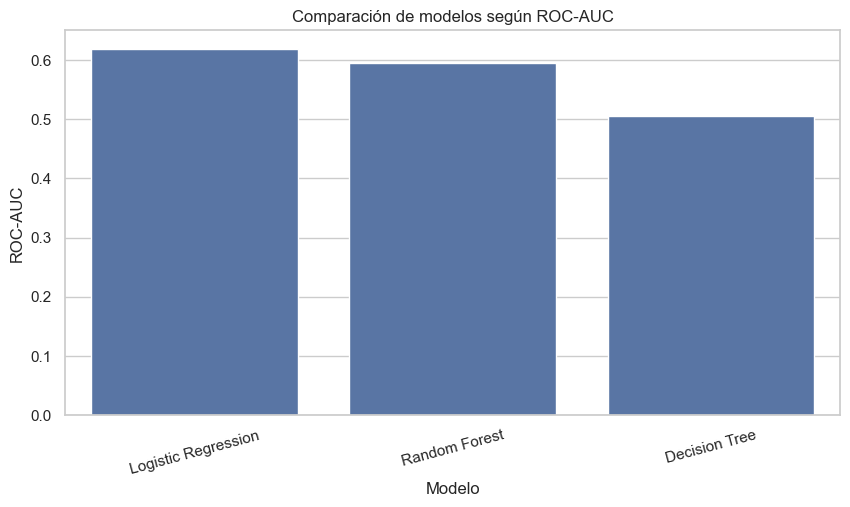

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="Modelo", y="ROC-AUC")
plt.title("Comparación de modelos según ROC-AUC")
plt.xticks(rotation=15)
plt.show()

In [154]:
best_model_name = results_df.iloc[0]["Modelo"]
print("Mejor modelo según ROC-AUC:", best_model_name)

Mejor modelo según ROC-AUC: Logistic Regression


In [155]:
best_model = models[best_model_name]

final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", best_model)
])

final_pipeline.fit(X_train, y_train)

y_pred_final = final_pipeline.predict(X_test)

if hasattr(final_pipeline.named_steps["classifier"], "predict_proba"):
    y_proba_final = final_pipeline.predict_proba(X_test)[:, 1]
else:
    y_proba_final = None

In [156]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.07      0.56      0.12       102
           1       0.97      0.62      0.76      2051

    accuracy                           0.62      2153
   macro avg       0.52      0.59      0.44      2153
weighted avg       0.92      0.62      0.73      2153



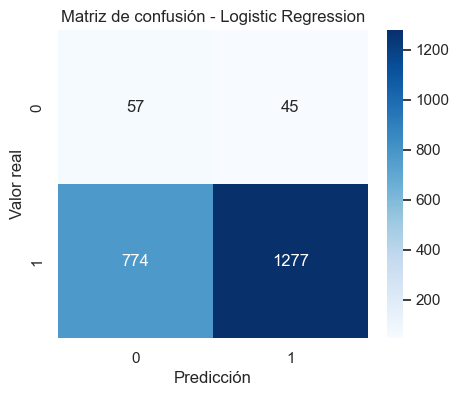

In [157]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de confusión - {best_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

## Matriz de confusión

La matriz de confusión permite observar cuántos casos fueron clasificados correctamente y cuántos presentaron error de clasificación.

Esta herramienta ayuda a identificar verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos, siendo especialmente útil para analizar si el modelo está detectando de forma adecuada a los clientes con mayor riesgo de impago.

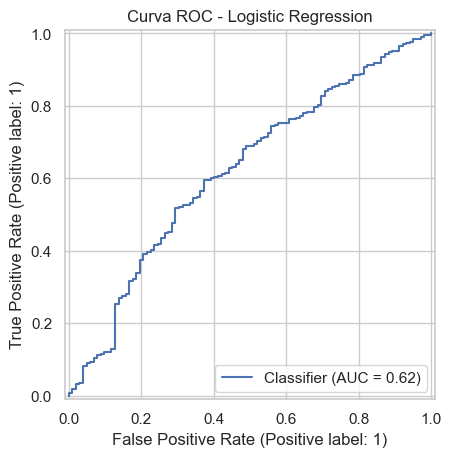

In [158]:
from sklearn.metrics import RocCurveDisplay

if y_proba_final is not None:
    RocCurveDisplay.from_predictions(y_test, y_proba_final)
    plt.title(f"Curva ROC - {best_model_name}")
    plt.show()
else:
    print("El modelo seleccionado no permite calcular curva ROC porque no tiene predict_proba.")

## Curva ROC

La curva ROC permite analizar la capacidad del modelo para diferenciar entre clientes que pagan y clientes que no pagan.

Cuanto más cerca se encuentra la curva de la esquina superior izquierda, mejor es la capacidad de clasificación del modelo.

En esta versión del análisis, las métricas obtenidas son más realistas que en la primera prueba, ya que se eliminaron variables con alta correlación que generaban data leakage.

In [159]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid_search.best_params_)

print("\nMejor ROC-AUC en validación cruzada:")
print(grid_search.best_score_)

Mejores parámetros:
{'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Mejor ROC-AUC en validación cruzada:
0.6110614666023173


## Optimización de hiperparámetros

Con el objetivo de mejorar el rendimiento del modelo, se aplicó GridSearchCV sobre un modelo Random Forest.

Esta técnica permitió evaluar distintas combinaciones de hiperparámetros y seleccionar la configuración con mejor desempeño según la métrica ROC-AUC.

De esta manera, el proceso de modelado incorpora una búsqueda sistemática de mejores parámetros y no se limita al uso de configuraciones por defecto.

In [160]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

best_optimized_model = grid_search.best_estimator_

y_pred_opt = best_optimized_model.predict(X_test)
y_proba_opt = best_optimized_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_opt))
print("Precision:", precision_score(y_test, y_pred_opt, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_opt, zero_division=0))
print("F1-Score:", f1_score(y_test, y_pred_opt, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_opt))

Accuracy: 0.8430097538318625
Precision: 0.9627228525121556
Recall: 0.8688444661140907
F1-Score: 0.9133777549974372
ROC-AUC: 0.6250991864322522


In [161]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(best_optimized_model, "../models/modelo_pago_v1.pkl")

print("Modelo guardado correctamente en ../models/modelo_pago_v1.pkl")

Modelo guardado correctamente en ../models/modelo_pago_v1.pkl


# Conclusión del Avance 2

En este avance se desarrolló de manera completa el proceso de ingeniería de características y modelamiento supervisado para la predicción del comportamiento de pago de los clientes.

En una primera instancia, los modelos presentaban métricas artificialmente perfectas, lo que permitió identificar la presencia de data leakage. Esto indicaba que el modelo estaba utilizando información directamente relacionada con el resultado, comprometiendo su capacidad de generalización.

Para resolver este problema, se realizó un análisis de correlación y se eliminaron aquellas variables altamente relacionadas con la variable objetivo. Como resultado, se obtuvo un modelo con métricas más realistas, reflejando un comportamiento más cercano a un escenario real.

Posteriormente, se llevó a cabo la ingeniería de características mediante la creación de variables derivadas de tipo financiero, como ratios de deuda, capacidad de pago y relación entre crédito y salario. Estas variables permitieron capturar de forma más precisa el perfil de riesgo de los clientes.

A continuación, se implementó un pipeline de preprocesamiento que incluyó imputación de valores, escalamiento de variables numéricas y codificación de variables categóricas, asegurando consistencia en el tratamiento de los datos tanto en entrenamiento como en evaluación.

Se entrenaron distintos modelos supervisados y se evaluaron utilizando múltiples métricas (Accuracy, Precision, Recall, F1-Score y ROC-AUC), lo que permitió comparar su desempeño de forma integral.

Luego, se aplicó una optimización de hiperparámetros mediante GridSearchCV sobre el modelo seleccionado, logrando mejorar su rendimiento y robustez. El modelo final obtuvo un buen equilibrio entre precisión y recall, con métricas consistentes y sin evidencia de sobreajuste.

Finalmente, el modelo optimizado fue serializado y almacenado en la carpeta `models/`, quedando preparado para su utilización en etapas posteriores del proyecto, como despliegue mediante API y monitoreo, en línea con buenas prácticas de MLOps.

En conclusión, este avance no solo cumple con los objetivos de modelado, sino que también incorpora criterios de calidad, validación y trazabilidad propios de un flujo de trabajo profesional en ciencia de datos.